1. Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd
from scipy.ndimage import zoom, gaussian_filter
from skimage.transform import resize

2. Utilities

In [3]:
# ----------------------------
# Memory calculator
# ----------------------------
def calc_memory_usage(volume):
    num_voxels = np.prod(volume.shape)
    return num_voxels * 4 / (1024**2)  # MB for float32

# ----------------------------
# Normalization
# ----------------------------
def percentile_normalize(volume, low=0.5, high=99.5):
    vmin, vmax = np.percentile(volume, [low, high])
    volume = np.clip(volume, vmin, vmax)
    volume = 2.0 * (volume - vmin) / (vmax - vmin + 1e-8) - 1.0
    return volume.astype(np.float32)

# ----------------------------
# Downsample XY
# ----------------------------
def downsample_xy(volume, factor=8):
    zoom_factors = (1.0, 1.0/factor, 1.0/factor)
    return zoom(volume, zoom_factors, order=1)

# ----------------------------
# Pad or crop Z
# ----------------------------
def pad_or_crop_z(volume, target_z=128):
    z_len = volume.shape[0]
    if z_len >= target_z:
        start = (z_len - target_z) // 2
        return volume[start:start+target_z], -start
    else:
        pad_before = (target_z - z_len) // 2
        pad_after = target_z - z_len - pad_before
        return np.pad(volume, ((pad_before, pad_after),(0,0),(0,0)), mode="constant"), pad_before

# ----------------------------
# Gaussian heatmap
# ----------------------------
def generate_gaussian_heatmap(coords, shape, sigma=2):
    heatmap = np.zeros(shape, dtype=np.float32)
    for z,y,x in coords:
        if 0 <= z < shape[0] and 0 <= y < shape[1] and 0 <= x < shape[2]:
            heatmap[int(z), int(y), int(x)] = 1.0
    return gaussian_filter(heatmap, sigma=sigma)

# ----------------------------
# Show helper
# ----------------------------
def show_two(vol1, title1, vol2, title2, z):
    fig, axes = plt.subplots(1,2,figsize=(12,5))
    axes[0].imshow(vol1[z], cmap="gray")
    axes[0].set_title(title1)
    axes[1].imshow(vol2[z], cmap="gray")
    axes[1].set_title(title2)
    plt.show()

3. Load Example Tomogram & GT Coords

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

# --- Paths ---
BASE_DATA_DIR = Path("/data/horse/ws/rabo074f-team_project/byu-locating-bacterial-flagellar-motors-2025/train")
LABELS_CSV = "/data/horse/ws/rabo074f-team_project/byu-locating-bacterial-flagellar-motors-2025/train_labels.csv"

labels_df = pd.read_csv(LABELS_CSV)

# --- Pick one tomo to inspect ---
tomo_id = "tomo_01a877"  # change as needed
tomo_dir = BASE_DATA_DIR / tomo_id

# --- Load slices (mirror training code) ---
slice_paths = sorted(tomo_dir.glob("slice_*.jpg"))
if not slice_paths:
    raise RuntimeError(f"No slices found in {tomo_dir}")

vol_slices = [np.array(Image.open(p).convert("L"), dtype=np.float32) for p in slice_paths]
volume = np.stack(vol_slices, axis=0)

# --- Load GT coords (mirror training code) ---
df_tomo = labels_df[labels_df["tomo_id"] == tomo_id]
coords = df_tomo[["Motor axis 0","Motor axis 1","Motor axis 2"]].values if not df_tomo.empty else np.empty((0,3), dtype=int)
if coords.size > 0:
    coords = coords[~np.any(coords == -1, axis=1)]
coords = coords.astype(np.float32)

# --- Report ---
def calc_memory_usage(arr):
    return arr.nbytes / (1024**2)  # MB

print("tomo_id:", tomo_id)
print("Volume shape:", volume.shape, f"| ~{calc_memory_usage(volume):.2f} MB")
print("CSV rows for tomo:", len(df_tomo))
print("Original (CSV) coords (Z,Y,X):", coords)

tomo_id: tomo_01a877
Volume shape: (300, 960, 928) | ~1019.53 MB
CSV rows for tomo: 1
Original (CSV) coords (Z,Y,X): [[147. 638. 286.]]


Step 1 — Normalization

Before norm: (300, 960, 928) | ~1019.53 MB


After  norm: (300, 960, 928) | ~1019.53 MB


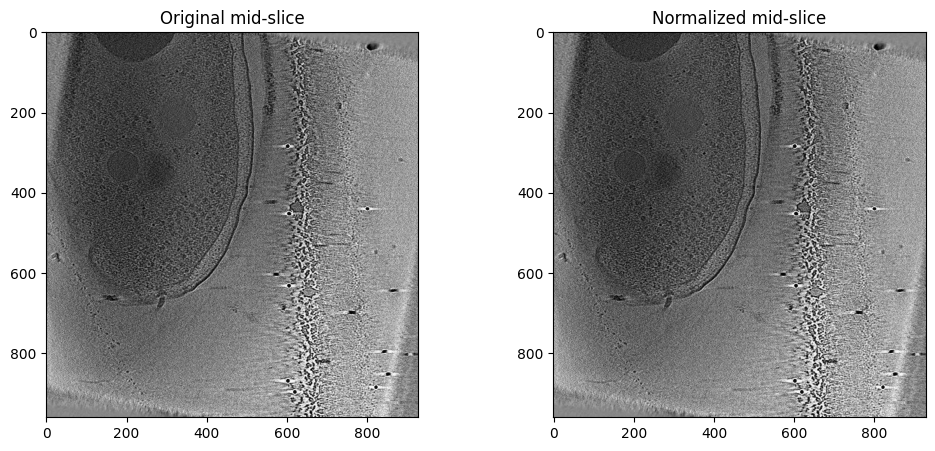

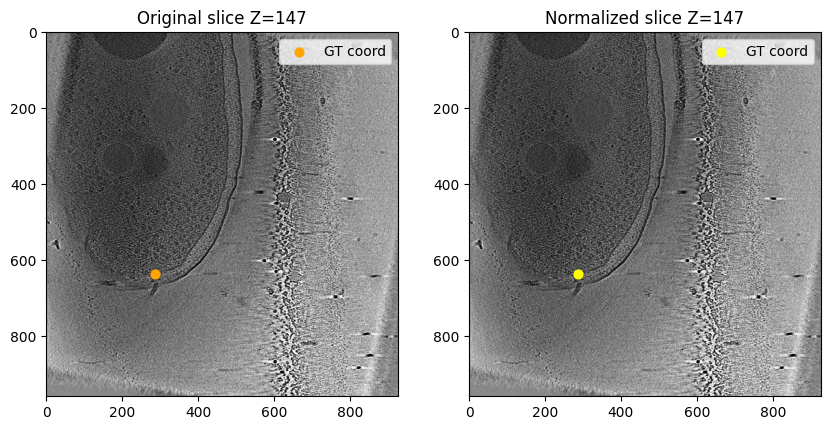

In [6]:
import os

# --- Before and after normalization ---
print("Before norm:", volume.shape, f"| ~{calc_memory_usage(volume):.2f} MB")

vol_norm = percentile_normalize(volume)
print("After  norm:", vol_norm.shape, f"| ~{calc_memory_usage(vol_norm):.2f} MB")

# --- Mid-slice visualization ---
mid_z = volume.shape[0] // 2
show_two(
    volume, "Original mid-slice",
    vol_norm, "Normalized mid-slice",
    z=mid_z
)

# --- Plot GT coords (orange = original, yellow = normalized for now same coords) ---
z, y, x = coords[0]
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(volume[int(z)], cmap="gray")
plt.scatter(x, y, c="orange", s=40, label="GT coord")
plt.title(f"Original slice Z={int(z)}")
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(vol_norm[int(z)], cmap="gray")
plt.scatter(x, y, c="yellow", s=40, label="GT coord")
plt.title(f"Normalized slice Z={int(z)}")
plt.legend()

# Save as PDF
save_dir = "images_hpc/preprocessing_visualization"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/gt_coords_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Step 2 — Downsample XY

Before downsample: (300, 960, 928) | ~1019.53 MB
After  downsample: (300, 120, 116) | ~15.93 MB


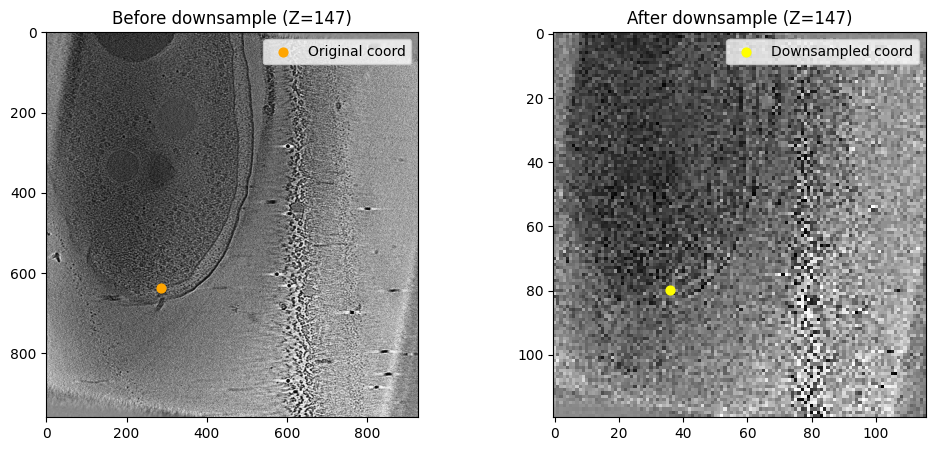

In [13]:
# --- Downsample XY ---
vol_ds = downsample_xy(vol_norm, factor=8)

# Adjust coords
coords_ds = coords.copy()
coords_ds[:, 1] /= 8.0
coords_ds[:, 2] /= 8.0

print("Before downsample:", vol_norm.shape, f"| ~{calc_memory_usage(vol_norm):.2f} MB")
print("After  downsample:", vol_ds.shape, f"| ~{calc_memory_usage(vol_ds):.2f} MB")

# --- Pick one motor coord ---
z0, y0, x0 = coords[0]       # before
z1, y1, x1 = coords_ds[0]    # after

# --- Side-by-side visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(vol_norm[int(z0)], cmap="gray")
axes[0].scatter(x0, y0, c="orange", s=40, label="Original coord")
axes[0].set_title(f"Before downsample (Z={int(z0)})")
axes[0].legend()

axes[1].imshow(vol_ds[int(z1)], cmap="gray")
axes[1].scatter(x1, y1, c="yellow", s=40, label="Downsampled coord")
axes[1].set_title(f"After downsample (Z={int(z1)})")
axes[1].legend()

# Save as PDF
save_dir = "images_hpc/preprocessing_visualization"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/downsample_xy_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Step 3 — Pad or Crop Z

Before pad/crop: (300, 120, 116) | ~15.93 MB
After  pad/crop: (128, 120, 116) | ~6.80 MB


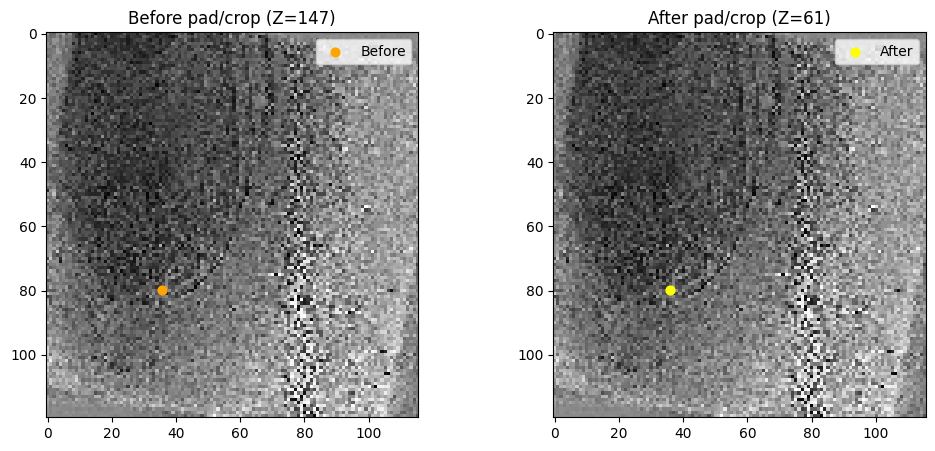

In [14]:
# --- Pad or crop Z to 128 ---
vol_z = vol_ds.copy()
coords_z = coords_ds.copy()

z_len = vol_ds.shape[0]
if z_len >= 128:
    # crop
    start = (z_len - 128) // 2
    vol_z = vol_ds[start:start+128, :, :]
    coords_z[:, 0] -= start
    z_offset = -start
else:
    # pad
    pad_before = (128 - z_len) // 2
    pad_after = 128 - z_len - pad_before
    vol_z = np.pad(vol_ds, ((pad_before, pad_after), (0, 0), (0, 0)), mode="constant")
    coords_z[:, 0] += pad_before
    z_offset = pad_before

print("Before pad/crop:", vol_ds.shape, f"| ~{calc_memory_usage(vol_ds):.2f} MB")
print("After  pad/crop:", vol_z.shape, f"| ~{calc_memory_usage(vol_z):.2f} MB")

# --- Pick one coord ---
z0, y0, x0 = coords_ds[0]   # before pad/crop
z1, y1, x1 = coords_z[0]    # after pad/crop

# --- Side-by-side visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(vol_ds[int(z0)], cmap="gray")
axes[0].scatter(x0, y0, c="orange", s=40, label="Before")
axes[0].set_title(f"Before pad/crop (Z={int(z0)})")
axes[0].legend()

axes[1].imshow(vol_z[int(z1)], cmap="gray")
axes[1].scatter(x1, y1, c="yellow", s=40, label="After")
axes[1].set_title(f"After pad/crop (Z={int(z1)})")
axes[1].legend()

# Save as PDF
save_dir = "images_hpc/preprocessing_visualization"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/pad_crop_z_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Step 4 — Resize XY to 128×128

Before resize XY: (128, 120, 116) | ~6.80 MB
After  resize XY: (128, 128, 128) | ~8.00 MB


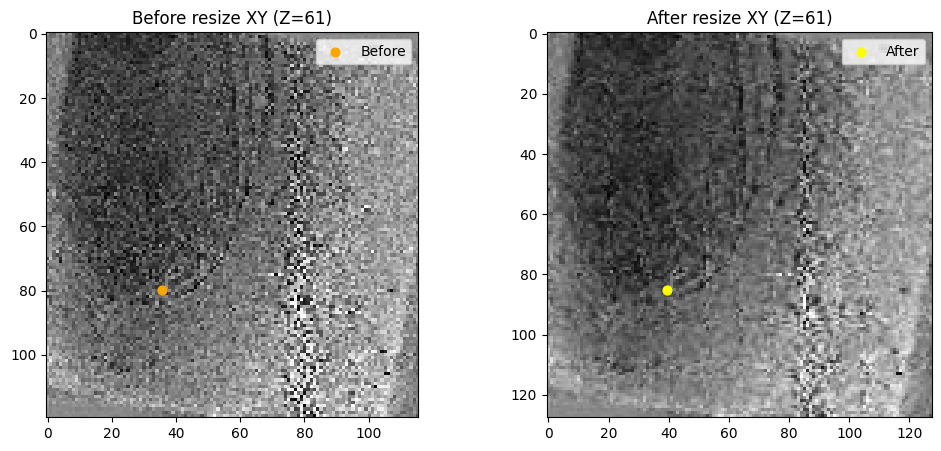

In [15]:
# --- Resize XY to 128x128 ---
vol_resized = resize(
    vol_z,
    (vol_z.shape[0], 128, 128),
    order=1,
    preserve_range=True,
    anti_aliasing=True
).astype(np.float32)

coords_resized = coords_z.copy()
coords_resized[:, 1] *= (128.0 / vol_z.shape[1])  # scale Y
coords_resized[:, 2] *= (128.0 / vol_z.shape[2])  # scale X

print("Before resize XY:", vol_z.shape, f"| ~{calc_memory_usage(vol_z):.2f} MB")
print("After  resize XY:", vol_resized.shape, f"| ~{calc_memory_usage(vol_resized):.2f} MB")

# --- Pick one coord ---
z0, y0, x0 = coords_z[0]         # before resize
z1, y1, x1 = coords_resized[0]   # after resize

# --- Side-by-side visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(vol_z[int(z0)], cmap="gray")
axes[0].scatter(x0, y0, c="orange", s=40, label="Before")
axes[0].set_title(f"Before resize XY (Z={int(z0)})")
axes[0].legend()

axes[1].imshow(vol_resized[int(z1)], cmap="gray")
axes[1].scatter(x1, y1, c="yellow", s=40, label="After")
axes[1].set_title(f"After resize XY (Z={int(z1)})")
axes[1].legend()

# Save as PDF
save_dir = "images_hpc/preprocessing_visualization"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/resize_xy_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Heatmap Generation

Final volume: (128, 128, 128) | ~8.00 MB
Heatmap shape: (128, 128, 128)


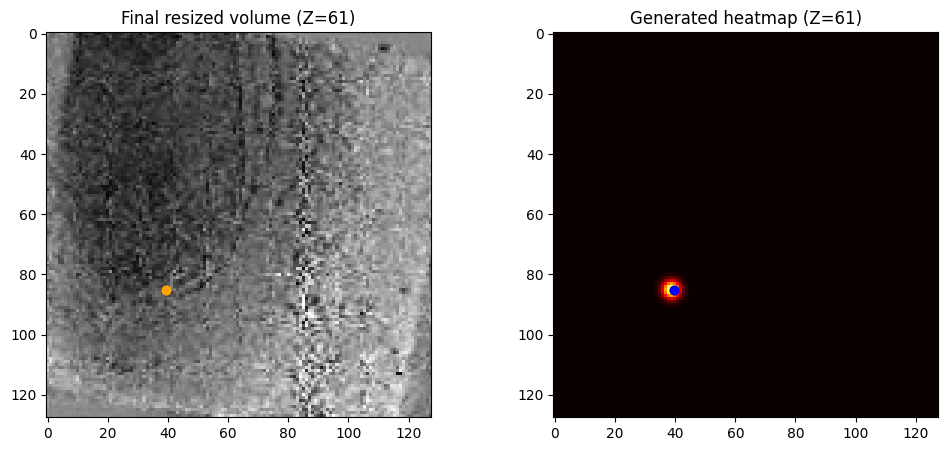

In [16]:
# --- Generate Gaussian heatmap ---
heatmap = generate_gaussian_heatmap(coords_resized, vol_resized.shape, sigma=2)

print("Final volume:", vol_resized.shape, f"| ~{calc_memory_usage(vol_resized):.2f} MB")
print("Heatmap shape:", heatmap.shape)

z, y, x = coords_resized[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(vol_resized[int(z)], cmap="gray")
axes[0].scatter(x, y, c="orange", s=40)
axes[0].set_title(f"Final resized volume (Z={int(z)})")

axes[1].imshow(heatmap[int(z)], cmap="hot")
axes[1].scatter(x, y, c="blue", s=40)
axes[1].set_title(f"Generated heatmap (Z={int(z)})")

# Save as PDF
plt.savefig(f"{save_dir}/gaussian_heatmap_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Effective Voxel Size

In [11]:
RAW_VOXEL_SIZE_ANGSTROM = np.array([13.68, 109.44, 109.44])  # (Z,Y,X)
orig_z, orig_y, orig_x = volume.shape

eff_voxel_size = np.array([
    RAW_VOXEL_SIZE_ANGSTROM[0],
    RAW_VOXEL_SIZE_ANGSTROM[1] * (orig_y / 128.0),
    RAW_VOXEL_SIZE_ANGSTROM[2] * (orig_x / 128.0),
])

print("Effective voxel size (Å):", eff_voxel_size)

Effective voxel size (Å): [ 13.68 820.8  793.44]


Augmentation Preview

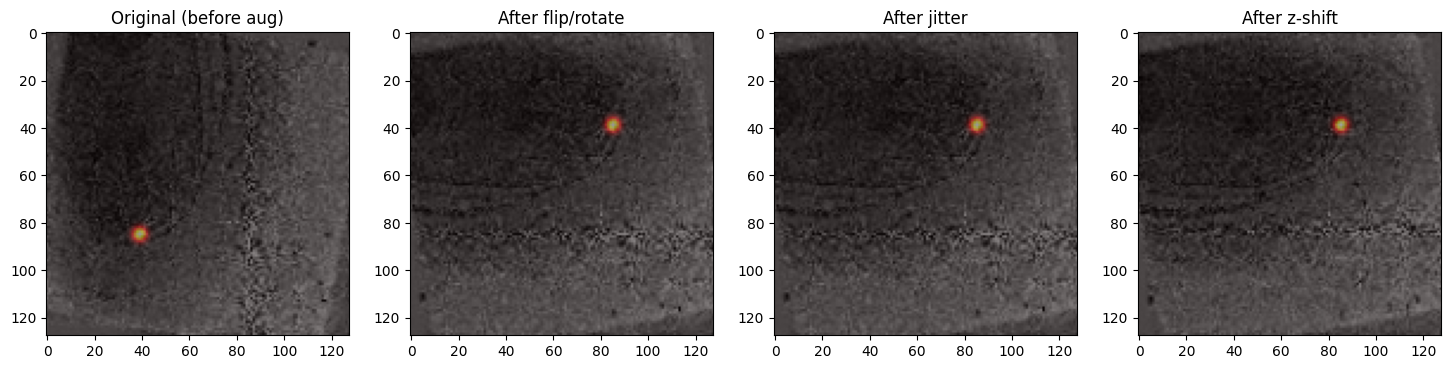

In [17]:
# ----------------------------
# Augmentation utilities (copied from training code)
# ----------------------------
def random_flip_rotate(volume, heatmap):
    if np.random.rand() < 0.5:
        volume = np.flip(volume, axis=1).copy()
        heatmap = np.flip(heatmap, axis=1).copy()
    if np.random.rand() < 0.5:
        volume = np.flip(volume, axis=2).copy()
        heatmap = np.flip(heatmap, axis=2).copy()
    k = np.random.randint(0,4)
    if k > 0:
        volume = np.rot90(volume,k,axes=(1,2)).copy()
        heatmap = np.rot90(heatmap,k,axes=(1,2)).copy()
    return volume, heatmap

def random_intensity_jitter(volume):
    if np.random.rand() < 0.5:
        scale = 0.9 + 0.2 * np.random.rand()
        shift = 0.1 * (2 * np.random.rand() - 1)
        volume = volume * scale + shift
        volume = np.clip(volume, -1, 1)
    return volume

def random_z_shift(volume, heatmap, max_shift=10):
    if np.random.rand() < 0.5:
        shift = np.random.randint(-max_shift, max_shift + 1)
        volume = np.roll(volume, shift, axis=0)
        heatmap = np.roll(heatmap, shift, axis=0)
        if shift > 0:
            volume[:shift] = 0
            heatmap[:shift] = 0
        elif shift < 0:
            volume[shift:] = 0
            heatmap[shift:] = 0
    return volume, heatmap


# ----------------------------
# augmentation visualization
# ----------------------------
z = int(coords_resized[0,0])  # slice with motor

# Step 1: Flip/Rotate
vol_step1, heatmap_step1 = random_flip_rotate(vol_resized.copy(), heatmap.copy())

# Step 2: Intensity jitter
vol_step2 = random_intensity_jitter(vol_step1.copy())
heatmap_step2 = heatmap_step1  # unchanged

# Step 3: Z-shift
vol_step3, heatmap_step3 = random_z_shift(vol_step2.copy(), heatmap_step2.copy())


# ----------------------------
# results
# ----------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(vol_resized[z], cmap="gray")
axes[0].imshow(heatmap[z], cmap="hot", alpha=0.5)
axes[0].set_title("Original (before aug)")

axes[1].imshow(vol_step1[z], cmap="gray")
axes[1].imshow(heatmap_step1[z], cmap="hot", alpha=0.5)
axes[1].set_title("After flip/rotate")

axes[2].imshow(vol_step2[z], cmap="gray")
axes[2].imshow(heatmap_step2[z], cmap="hot", alpha=0.5)
axes[2].set_title("After jitter")

axes[3].imshow(vol_step3[z], cmap="gray")
axes[3].imshow(heatmap_step3[z], cmap="hot", alpha=0.5)
axes[3].set_title("After z-shift")

# Save as PDF
plt.savefig(f"{save_dir}/augmentation_steps_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()